# 01 Dataset Building
This notebook explains how repository URLs become a training dataset for the defect prediction model.
The original script remains the source of truth so the application logic is not changed.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

WORKSPACE = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_PATH = WORKSPACE / "data" / "github_defect_dataset.csv"
REPO_LIST_PATH = WORKSPACE / "data" / "repositories.txt"
WORKSPACE

WindowsPath('D:/Academic Assignments/Final Year Project/SDP-for-GitHub/ml_workspace')

## Repository list
Each line in `repositories.txt` is one public GitHub repository used for dataset collection.

In [2]:
repositories = [line.strip() for line in REPO_LIST_PATH.read_text(encoding="utf-8").splitlines() if line.strip() and not line.strip().startswith("#")]
pd.DataFrame({"repository_url": repositories})

,repository_url
0,https://github.com/bitcoin/bitcoin
1,https://github.com/opencv/opencv
2,https://github.com/electron/electron
3,https://github.com/spring-projects/spring-fram...
4,https://github.com/apache/kafka
5,https://github.com/elastic/elasticsearch
6,https://github.com/django/django
7,https://github.com/pandas-dev/pandas
8,https://github.com/psf/requests


## Optional build command
Run this cell only when you want to rebuild the dataset from the repository list.
Large repositories can take a long time so use conservative limits first.

In [ ]:
import subprocess
#Uncomment when you want to rebuild the dataset
#subprocess.run(["python", "scripts/build_multi_repo_dataset.py"], cwd=WORKSPACE, check=True)

## Dataset overview
These charts help explain whether the dataset has enough examples and whether labels are balanced.

In [3]:
df = pd.read_csv(DATA_PATH)
display(df.head())
display(df.describe(include="all").transpose().head(20))

,file_path,language,nosi,dit,cbo,rfc,loc,comparisonsQty,returnQty,wmc,...,last_change_lines_deleted,last_change_churn,last_change_file_count,author_file_change_count,repo_name,repo_url,commit_sha,source_commit_used,commit_message,defect
0,src/rpc/net.cpp,C++,2,1,38,280,1156,254,48,109,...,0,60,4,14,bitcoin,https://github.com/bitcoin/bitcoin,fa864b937e1b36f5a8fe989467360988a03637ec,fa864b937e1b36f5a8fe989467360988a03637ec,refactor: [rpc] Remove confusing and brittle i...,0
1,src/node/miner.h,C++,0,1,12,13,139,74,9,12,...,13,30,3,1,bitcoin,https://github.com/bitcoin/bitcoin,2c5242d24f47fd6aa828dbacaf2b678030db4488,2d3edd9640f32657e292974967f5d18ee4263230,multi_index: fix compilation failure with boos...,1
2,src/txmempool.h,C++,2,2,31,52,362,208,32,40,...,3,8,3,1,bitcoin,https://github.com/bitcoin/bitcoin,2c5242d24f47fd6aa828dbacaf2b678030db4488,2d3edd9640f32657e292974967f5d18ee4263230,multi_index: fix compilation failure with boos...,1
3,src/txrequest.cpp,C++,16,1,16,191,460,386,44,98,...,5,13,3,1,bitcoin,https://github.com/bitcoin/bitcoin,2c5242d24f47fd6aa828dbacaf2b678030db4488,2d3edd9640f32657e292974967f5d18ee4263230,multi_index: fix compilation failure with boos...,1
4,src/validation.cpp,C++,155,2,68,1741,4198,1565,415,822,...,20,42,1,0,bitcoin,https://github.com/bitcoin/bitcoin,076629a3c19ceb779ddc251183c09807327efd3d,b110304705e1e1f97c88c4bb1455ab03c909450a,validation: correct lifetime of precomputed tx...,1


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
file_path,2797,1509,pandas/core/frame.py,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
language,2797,3,Java,1103,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nosi,2797.0,NaN,NaN,NaN,20.766536,49.098499,0.0,0.0,3.0,18.0,438.0
dit,2797.0,NaN,NaN,NaN,1.526278,0.499398,1.0,1.0,2.0,2.0,2.0
cbo,2797.0,NaN,NaN,NaN,37.191276,57.120179,0.0,8.0,18.0,41.0,656.0
rfc,2797.0,NaN,NaN,NaN,173.198427,329.455687,0.0,12.0,58.0,181.0,3066.0
loc,2797.0,NaN,NaN,NaN,704.642117,1492.586224,0.0,94.0,250.0,686.0,15461.0
comparisonsQty,2797.0,NaN,NaN,NaN,208.524848,499.34671,0.0,22.0,64.0,189.0,5296.0
returnQty,2797.0,NaN,NaN,NaN,44.937075,77.890814,0.0,4.0,16.0,48.0,1108.0
wmc,2797.0,NaN,NaN,NaN,110.562031,203.487215,0.0,9.0,36.0,113.0,2072.0


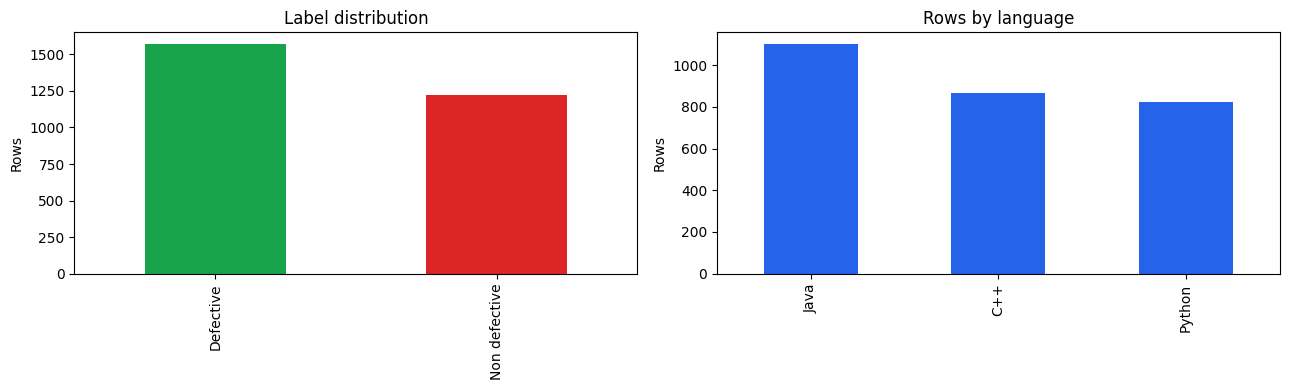

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
label_counts = df["defect"].map({0: "Non defective", 1: "Defective"}).value_counts()
label_counts.plot(kind="bar", ax=axes[0], color=["#16a34a", "#dc2626"])
axes[0].set_title("Label distribution")
axes[0].set_xlabel("")
axes[0].set_ylabel("Rows")
language_counts = df.get("language", pd.Series(dtype=str)).value_counts()
language_counts.plot(kind="bar", ax=axes[1], color="#2563eb")
axes[1].set_title("Rows by language")
axes[1].set_xlabel("")
axes[1].set_ylabel("Rows")
plt.tight_layout()
plt.show()